# СО СТАРОГО ЧЕКПОЙНТА

In [1]:
from datasets import load_from_disk
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

C:\Users\vedma\anaconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
likes = load_from_disk('dataset-parts/yambda_likes')
dislikes = load_from_disk('dataset-parts/yambda_dislikes')
# listens = load_from_disk('dataset-parts/yambda_listens')

likes_table = likes.data.table
dislikes_table = dislikes.data.table
# listens_table = listens.data.table


likes_df = likes_table.to_pandas()
dislikes_df = dislikes_table.to_pandas()
# listens_df = listens_table.to_pandas()

likes_df['event_type'] = 'like'
dislikes_df['event_type'] = 'dislike'
# listens_df['event_type'] = 'listen'

# yambda_df = pd.concat([likes_df, dislikes_df, listens_df], ignore_index=True)
yambda_df = pd.concat([likes_df, dislikes_df], ignore_index=True)

yambda_df = yambda_df.sort_values('timestamp')

yambda_df

,uid,timestamp,item_id,is_organic,played_ratio_pct,track_length_seconds,event_type
968656,794500,75,5890868,1,NaN,NaN,dislike
968657,794500,75,5559703,1,NaN,NaN,dislike
968658,794500,75,7316012,1,NaN,NaN,dislike
968659,794500,75,4955025,1,NaN,NaN,dislike
968660,794500,75,6693536,1,NaN,NaN,dislike
...,...,...,...,...,...,...,...
713215,809400,25999905,1264650,1,NaN,NaN,like
146824,168100,25999910,83561,1,NaN,NaN,like
933449,411500,25999945,6603749,1,NaN,NaN,dislike
360130,411500,25999945,1342000,1,NaN,NaN,like


In [5]:
yambda_df_organic = yambda_df[yambda_df['is_organic'] == 1].drop(['is_organic'], axis=1)

yambda_df_organic

,uid,timestamp,item_id,played_ratio_pct,track_length_seconds,event_type
968656,794500,75,5890868,NaN,NaN,dislike
968657,794500,75,5559703,NaN,NaN,dislike
968658,794500,75,7316012,NaN,NaN,dislike
968659,794500,75,4955025,NaN,NaN,dislike
968660,794500,75,6693536,NaN,NaN,dislike
...,...,...,...,...,...,...
146823,168100,25999890,4626898,NaN,NaN,like
713215,809400,25999905,1264650,NaN,NaN,like
146824,168100,25999910,83561,NaN,NaN,like
933449,411500,25999945,6603749,NaN,NaN,dislike


In [10]:
weak_ticks = (7 * 24 * 3600) // 5
year_ticks = (365 * 24 * 3600) // 5

weak_ticks, year_ticks

(120960, 6307200)

In [14]:
max_time = yambda_df_organic['timestamp'].max()

test_start = max_time - weak_ticks
train_start = test_start - year_ticks

In [16]:
train_df = yambda_df_organic[
    (yambda_df_organic['timestamp'] >= train_start) &
    (yambda_df_organic['timestamp'] < test_start)
]

test_df = yambda_df_organic[yambda_df_organic['timestamp'] >= test_start]

In [18]:
users_activity = train_df['uid'].value_counts()

Длина истории пользователя

In [21]:
user_time_span = (
    train_df.groupby('uid')['timestamp']
    .agg(['min', 'max'])
    .assign(span=lambda x: x['max'] - x['min'])
)

user_time_span['span'].describe()

count    7.149000e+03
mean     3.400789e+06
std      2.218284e+06
min      0.000000e+00
25%      1.209575e+06
50%      4.018570e+06
75%      5.420815e+06
max      6.302335e+06
Name: span, dtype: float64

Распределение активности по айтемам

In [24]:
items_activity = train_df['item_id'].value_counts()
items_activity.describe()

count    73212.000000
mean         2.569948
std          5.723127
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max        337.000000
Name: count, dtype: float64

Популярности айтемов

Длина жизни трека в данных

In [28]:
item_time_span = (
    train_df.groupby('item_id')['timestamp']
    .agg(['min', 'max'])
    .assign(span=lambda x: x['max'] - x['min'])
)

item_time_span['span'].describe()

count    7.321200e+04
mean     1.034187e+06
std      1.786547e+06
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.505585e+06
max      6.303475e+06
Name: span, dtype: float64

In [30]:
quantiles = [0.25, 0.5, 0.75, 0.8, 0.9, 0.95, 0.99, 0.999]

for quantile in quantiles:
    print(f'Listens quntile {quantile * 100}%: {users_activity.quantile(quantile)}')

Listens quntile 25.0%: 3.0
Listens quntile 50.0%: 10.0
Listens quntile 75.0%: 25.0
Listens quntile 80.0%: 31.0
Listens quntile 90.0%: 56.0
Listens quntile 95.0%: 90.0
Listens quntile 99.0%: 231.0799999999981
Listens quntile 99.9%: 838.4120000000239


In [32]:
groups = pd.qcut(users_activity, q=[0, 0.3, 0.6, 0.9, 0.95, 1.0], duplicates='drop')

counts = groups.value_counts().sort_index()

print('Users activity distribution')
print(counts)

Users activity distribution
count
(0.999, 4.0]      2258
(4.0, 14.0]       2075
(14.0, 56.0]      2116
(56.0, 90.0]       346
(90.0, 7184.0]     354
Name: count, dtype: int64


Можно увидеть, что активные/"нормальные" пользователи сидят между 60-ым 95-ым перцентилями, я бы даже поднял нижнюю границу до 70

In [35]:
low_threshold = users_activity.quantile(0.7)
high_threshold = users_activity.quantile(0.95)

active_user_ids = users_activity[
    (users_activity >= low_threshold) & 
    (users_activity <= high_threshold)
].index

df_train_active = train_df[train_df['uid'].isin(active_user_ids)].reset_index(drop=True)

In [37]:
df_train_active['uid'].value_counts().describe()

count    1809.000000
mean       40.697070
std        17.799771
min        21.000000
25%        26.000000
50%        35.000000
75%        51.000000
max        90.000000
Name: count, dtype: float64

Стало получше. Мы убрали неактивных пользователей, убрали супер активных.

Может показаться странным, что за год люди слушали так мало треков, но эта статистика берется по данным с  explicit фидбеком, которого всегда меньше

In [40]:
df_train_active

,uid,timestamp,item_id,played_ratio_pct,track_length_seconds,event_type
0,627100,19571995,453808,NaN,NaN,dislike
1,349300,19572125,219150,NaN,NaN,like
2,349300,19572125,1949803,NaN,NaN,like
3,559100,19572260,1044085,NaN,NaN,like
4,559100,19572260,2033546,NaN,NaN,like
...,...,...,...,...,...,...
73616,488000,25878780,5302349,NaN,NaN,like
73617,488000,25878780,6317616,NaN,NaN,like
73618,32500,25878800,3135264,NaN,NaN,like
73619,32500,25878800,5016149,NaN,NaN,like


In [42]:
df_train_active.uid.nunique(), df_train_active.item_id.nunique()

(1809, 35620)

Сейчас у нас есть следующие формы взаимодействия:
* Лайк
* Дизлайк
* Прослушивание

Из них нужно сформировать разные матрицы взаимодействий: бинарные, знаковые, взвешанные

Пока что мы делали препроцессинг для лайков и дизлайков, поэтому попробуем поработать только с этими видами фидбека 

In [45]:
counts = df_train_active.groupby(['uid', 'item_id'])['item_id'].transform('size')

duplicates_full = df_train_active[counts > 1].sort_values(by=['uid', 'item_id'])

duplicates_full.uid.nunique()

928

Конфликтные пары uid-item

In [48]:
pair_event_stats = (
    df_train_active
    .groupby(['uid', 'item_id'])['event_type']
    .agg(
        n_events='count',
        n_unique_events='nunique',
        events=lambda x: tuple(sorted(set(x)))
    )
    .reset_index()
)

print('Пары с повторяющимися взаимодействиями:', (pair_event_stats['n_events'] > 1).sum())
print('Сочетается с конфликтующими типами событий.:', (pair_event_stats['n_unique_events'] > 1).sum())

pair_event_stats[pair_event_stats['n_unique_events'] > 1]['events'].value_counts().head(20)

Пары с повторяющимися взаимодействиями: 2344
Сочетается с конфликтующими типами событий.: 884


events
(dislike, like)    884
Name: count, dtype: int64

In [49]:
df_train_active.event_type.value_counts()

event_type
like       67654
dislike     5967
Name: count, dtype: int64

Тут видна такая ситуация: у нас 1809 пользователей, из которых тольо 928 совершали несколько действий (лайк и дизлайк), при этом большинство ставит лайки трекам. Думаю я сделаю такие взаимодействия: 
* значения -1 для дизлайков и 1 для лайков
* значения 0.1 для дизлайков и 1 для лайков. 

Для iALS буду использовать только 2-ой вариант, а для EASE, KNN попробую оба

In [53]:
train_df_sorted = train_df.sort_values(by=['uid', 'item_id', 'timestamp'])

final_states = train_df_sorted.drop_duplicates(subset=['uid', 'item_id'], keep='last').copy()

weight_mapping_sign = {
    'like': 1,
    'dislike': -1,
}

weight_mapping_weighted = {
    'like': 1,
    'dislike': 0.1,
}

final_states['interaction_sign'] = final_states['event_type'].map(weight_mapping_sign)
final_states['interaction_weighted'] = final_states['event_type'].map(weight_mapping_weighted)


user_item_sign = final_states[['uid', 'item_id', 'interaction_sign']].reset_index(drop=True)
user_item_weighted = final_states[['uid', 'item_id', 'interaction_weighted']].reset_index(drop=True)

In [55]:
user_item_sign.to_csv('user_item_sign_likes.csv')
user_item_weighted.to_csv('user_item_weighted_likes.csv')

In [56]:
train_users_sign = set(user_item_sign['uid'])
train_items_sign = set(user_item_sign['item_id'])

test_clean = test_df[
    test_df['uid'].isin(train_users_sign) &
    test_df['item_id'].isin(train_items_sign)
]

Доля cold-start в тесте

In [60]:
test_users_all = set(test_df['uid'])
test_items_all = set(test_df['item_id'])

train_users = set(user_item_sign['uid'])
train_items = set(user_item_sign['item_id'])

cold_users = test_df[~test_df['uid'].isin(train_users)]
cold_items = test_df[~test_df['item_id'].isin(train_items)]

print('Исходные тестовые строки:', len(test_df))
print('Чистые тестовые строки', len(test_clean))
print('Удалена тестовая доля:', round(1 - len(test_clean) / len(test_df), 4))

print('\nХолодные пользователи в тесте:', cold_users['uid'].nunique(), 'unique users')
print('Холодные айтемы в тесте:', cold_items['item_id'].nunique(), 'unique items')

print('\nДоля тестовых строк у невидимого пользователя:', round((~test_df['uid'].isin(train_users)).mean(), 4))
print('Доля тестовых строк с невидимым айтемом:', round((~test_df['item_id'].isin(train_items)).mean(), 4))

Исходные тестовые строки: 3848
Чистые тестовые строки 2663
Удалена тестовая доля: 0.308

Холодные пользователи в тесте: 35 unique users
Холодные айтемы в тесте: 1049 unique items

Доля тестовых строк у невидимого пользователя: 0.0327
Доля тестовых строк с невидимым айтемом: 0.2835


In [62]:
item2id = {k: v for v, k in enumerate(user_item_sign['item_id'].unique())}
user2id = {k: v for v, k in enumerate(user_item_sign['uid'].unique())}

id2item = {v: k for k, v in item2id.items()}
id2user = {v: k for k, v in user2id.items()}

In [64]:
user_item_sign['uidx'] = user_item_sign['uid'].map(user2id)
user_item_sign['item_idx'] = user_item_sign['item_id'].map(item2id)

user_item_weighted['uidx'] = user_item_weighted['uid'].map(user2id)
user_item_weighted['item_idx'] = user_item_weighted['item_id'].map(item2id)

In [66]:
user_item_sign

,uid,item_id,interaction_sign,uidx,item_idx
0,100,2263048,1,0,0
1,100,3526521,1,0,1
2,100,4927727,-1,0,2
3,100,5590855,1,0,3
4,300,1126058,1,1,4
...,...,...,...,...,...
177400,999900,1369814,1,7147,73211
177401,999900,1524105,1,7147,4486
177402,999900,2185191,1,7147,83
177403,999900,2467371,1,7147,25210


In [68]:
user_item_weighted

,uid,item_id,interaction_weighted,uidx,item_idx
0,100,2263048,1.0,0,0
1,100,3526521,1.0,0,1
2,100,4927727,0.1,0,2
3,100,5590855,1.0,0,3
4,300,1126058,1.0,1,4
...,...,...,...,...,...
177400,999900,1369814,1.0,7147,73211
177401,999900,1524105,1.0,7147,4486
177402,999900,2185191,1.0,7147,83
177403,999900,2467371,1.0,7147,25210


In [70]:
from scipy.sparse import csr_matrix

user_item_sign_sparse = csr_matrix(
    (
        user_item_sign['interaction_sign'],
        (user_item_sign['uidx'], user_item_sign['item_idx'])
    ),
    shape=(len(user2id), len(item2id))
)

user_item_weighted_sparse = csr_matrix(
    (
        user_item_weighted['interaction_weighted'],
        (user_item_weighted['uidx'], user_item_weighted['item_idx'])
    ),
    shape=(len(user2id), len(item2id))
)

Насколько разреженная матрица

In [73]:
n_users, n_items = user_item_sign_sparse.shape
nnz = user_item_sign_sparse.nnz
density = nnz / (n_users * n_items)

print('Matrix shape:', user_item_sign_sparse.shape)
print('Non-zero entries:', nnz)
print('Density:', density)
print('Sparsity:', 1 - density)

Matrix shape: (7149, 73212)
Non-zero entries: 177405
Density: 0.0003389520678500705
Sparsity: 0.9996610479321499


In [75]:
test_true = test_clean.groupby('uid')['item_id'].apply(set).to_dict()

# НОВЫЙ ЧЕКПОЙНТ

In [77]:
print(train_df.shape)
print(test_df.shape)
print(user_item_sign_sparse.shape)
print(user_item_weighted_sparse.shape)
print(len(user2id))
print(len(id2item))
print(len(test_true))

(188151, 6)
(3848, 6)
(7149, 73212)
(7149, 73212)
7149
73212
1043


In [79]:
!pip install gensim


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [80]:
from gensim.models import Word2Vec

последовательности треков по пользователям

In [84]:
seq_df = train_df.sort_values(["uid", "timestamp"])

seqs = (seq_df
    .groupby("uid")["item_id"]
    .apply(lambda x: [str(i) for i in x])
    .tolist())

seqs = [s for s in seqs if len(s) >= 2]
len(seqs), seqs[0][:10]

(6261, ['4927727', '5590855', '2263048', '3526521'])

In [86]:
i2v = Word2Vec(
    sentences=seqs,
    vector_size=64,
    window=5,
    min_count=1,
    workers=4,
    sg=1,
    negative=10,
    epochs=10,
    seed=42
)

In [87]:
len(i2v.wv), i2v.wv.vector_size

(73010, 64)

In [94]:
from sklearn.neighbors import NearestNeighbors

In [96]:
item_ids = [int(x) for x in i2v.wv.index_to_key]
emb = np.array([i2v.wv[str(i)] for i in item_ids]).astype("float32")

norms = np.linalg.norm(emb, axis=1, keepdims=True)
emb = emb / np.maximum(norms, 1e-12)

item_to_pos = {item: pos for pos, item in enumerate(item_ids)}
pos_to_item = {pos: item for pos, item in enumerate(item_ids)}

ann_index = NearestNeighbors(
    n_neighbors=11,
    metric="cosine",
    algorithm="brute",
    n_jobs=-1)

In [98]:
ann_index.fit(emb)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",11
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'brute'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'cosine'
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",-1


In [100]:
emb.shape

(73010, 64)

поиск похожих треков

In [103]:
test_item = item_ids[0]
q = emb[item_to_pos[test_item]].reshape(1, -1)
dist, idx = ann_index.kneighbors(q)

[pos_to_item[i] for i in idx[0][1:]]

[8213481,
 5635052,
 2651314,
 1164357,
 8031416,
 1586569,
 2511472,
 5862961,
 3033749,
 2745162]

функция рекомендаций через Item2Vec + ANN

In [110]:
def rec_i2v(uid, R, user2id, id2item, k=10, pool=200):
    if uid not in user2id:
        return []
    u = user2id[uid]
    seen_idx = R[u].nonzero()[1]
    seen = [id2item[int(i)] for i in seen_idx]
    seen_set = set(seen)
    vecs = []
    for item in seen:
        key = str(item)
        if key in i2v.wv:
            vecs.append(i2v.wv[key])
    if len(vecs) == 0:
        return []
    q = np.mean(vecs, axis=0).astype("float32")
    q = q / max(np.linalg.norm(q), 1e-12)
    sims = i2v.wv.similar_by_vector(q, topn=pool)
    out = []

    for item, score in sims:
        item = int(item)
        if item in seen_set:
            continue
        out.append(item)

        if len(out) >= k:
            break
    return out

In [112]:
i2v_recs = {}

for uid in test_true.keys():
    i2v_recs[uid] = rec_i2v(
        uid,
        user_item_sign_sparse,
        user2id,
        id2item,
        k=10)

In [114]:
def i2v_pred(uid, R, user2id, id2item, k=10):
    return i2v_recs.get(uid, [])[:k]

метрики

In [117]:
from metrics import recall_at_k, precision_at_k, ndcg_at_k, map_at_k, hit_rate_at_k

In [119]:
item2vec_ann_results = {
    "model": "Item2Vec + ANN",
    "Recall@10": recall_at_k(test_true, user_item_sign_sparse, user2id, id2item, 10, recommend_fn=i2v_pred),
    "Precision@10": precision_at_k(test_true, user_item_sign_sparse, user2id, id2item, 10, recommend_fn=i2v_pred),
    "NDCG@10": ndcg_at_k(test_true, user_item_sign_sparse, user2id, id2item, 10, recommend_fn=i2v_pred),
    "MAP@10": map_at_k(test_true, user_item_sign_sparse, user2id, id2item, 10, recommend_fn=i2v_pred),
    "HitRate@10": hit_rate_at_k(test_true, user_item_sign_sparse, user2id, id2item, 10, recommend_fn=i2v_pred)
}

item2vec_ann_results_df = pd.DataFrame([item2vec_ann_results])
item2vec_ann_results_df

,model,Recall@10,Precision@10,NDCG@10,MAP@10,HitRate@10
0,Item2Vec + ANN,0.003065,0.00077,0.00301,0.002413,0.00767


сбор анн кандидатов

In [122]:
cand_rows = []

for uid in test_true:
    recs = rec_i2v(uid, user_item_sign_sparse, user2id, id2item, k=50, pool=300)
    true_items = set(test_true[uid])

    for rank, item in enumerate(recs):
        cand_rows.append({
            "uid": uid,
            "item_id": item,
            "target": int(item in true_items),
            "ann_rank": rank + 1})

In [123]:
cand_df = pd.DataFrame(cand_rows)
cand_df.shape

(51950, 4)

In [124]:
cand_df["target"].value_counts(normalize=True)

target
0    0.9995
1    0.0005
Name: proportion, dtype: float64

популярность айтемов

In [126]:
item_popularity = (train_df
    .groupby("item_id")
    .size()
    .rename("item_popularity"))

item_like_ratio = (train_df
    .assign(is_like=(train_df["event_type"] == "like").astype(int))
    .groupby("item_id")["is_like"]
    .mean()
    .rename("item_like_ratio"))

активность пользователей

In [132]:
user_activity = (train_df
    .groupby("uid")
    .size()
    .rename("user_activity"))

In [134]:
cand_df = cand_df.merge(
    item_popularity,
    left_on="item_id",
    right_index=True,
    how="left")

cand_df = cand_df.merge(
    item_like_ratio,
    left_on="item_id",
    right_index=True,
    how="left")

cand_df = cand_df.merge(
    user_activity,
    left_on="uid",
    right_index=True,
    how="left")

In [136]:
cand_df = cand_df.fillna(0)

In [138]:
cand_df.head()

,uid,item_id,target,ann_rank,item_popularity,item_like_ratio,user_activity
0,1400,2977733,0,1,4,1.00,21
1,1400,7513303,0,2,4,1.00,21
2,1400,3675340,0,3,4,0.75,21
3,1400,4765470,0,4,4,0.50,21
4,1400,9181832,0,5,2,1.00,21


бустинг

In [141]:
from sklearn.model_selection import train_test_split

features = [
    "ann_rank",
    "item_popularity",
    "item_like_ratio",
    "user_activity"]

X = cand_df[features]
y = cand_df["target"]

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y)

In [145]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score

boost = HistGradientBoostingClassifier(
    max_iter=100,
    learning_rate=0.05,
    max_leaf_nodes=31,
    random_state=42)

boost.fit(X_train, y_train)

valid_pred = boost.predict_proba(X_valid)[:, 1]
roc_auc_score(y_valid, valid_pred)

0.752701011073664

feature importance

In [148]:
from sklearn.inspection import permutation_importance

imp = permutation_importance(
    boost,
    X_valid,
    y_valid,
    n_repeats=5,
    random_state=42,
    scoring="roc_auc")

imp_df = pd.DataFrame({
    "feature": features,
    "importance": imp.importances_mean
}).sort_values("importance", ascending=False)

In [150]:
imp_df

,feature,importance
3,user_activity,0.168181
1,item_popularity,0.051305
0,ann_rank,0.043172
2,item_like_ratio,0.024166


In [152]:
cand_df["boost_score"] = boost.predict_proba(
    cand_df[features]
)[:, 1]

In [154]:
reranked = (cand_df
    .sort_values(["uid", "boost_score"], ascending=[True, False]))

In [156]:
boost_rec_dict = (reranked
    .groupby("uid")["item_id"]
    .apply(list)
    .to_dict())

In [158]:
params = [
    {"max_iter": 50, "learning_rate": 0.05, "max_leaf_nodes": 15},
    {"max_iter": 100, "learning_rate": 0.05, "max_leaf_nodes": 31},
    {"max_iter": 150, "learning_rate": 0.03, "max_leaf_nodes": 31},
    {"max_iter": 100, "learning_rate": 0.1, "max_leaf_nodes": 15},
    {"max_iter": 200, "learning_rate": 0.03, "max_leaf_nodes": 63}]

rows = []
for p in params:
    mdl = HistGradientBoostingClassifier(**p, random_state=42)
    mdl.fit(X_train, y_train)
    pred = mdl.predict_proba(X_valid)[:, 1]
    rows.append({**p, "roc_auc": roc_auc_score(y_valid, pred)})

In [160]:
tune_df = pd.DataFrame(rows).sort_values("roc_auc", ascending=False)
tune_df

,max_iter,learning_rate,max_leaf_nodes,roc_auc
0,50,0.05,15,0.879528
1,100,0.05,31,0.752701
3,100,0.10,15,0.699364
2,150,0.03,31,0.585672
4,200,0.03,63,0.324689


In [162]:
best_params = tune_df.iloc[0][["max_iter", "learning_rate", "max_leaf_nodes"]].to_dict()
best_params["max_iter"] = int(best_params["max_iter"])
best_params["max_leaf_nodes"] = int(best_params["max_leaf_nodes"])

boost = HistGradientBoostingClassifier(**best_params, random_state=42)
boost.fit(X_train, y_train)
best_params

{'max_iter': 50, 'learning_rate': 0.05, 'max_leaf_nodes': 15}

In [164]:
cand_df["boost_score"] = boost.predict_proba(cand_df[features])[:, 1]

reranked = cand_df.sort_values(["uid", "boost_score"], ascending=[True, False])
boost_rec_dict = (
    reranked
    .groupby("uid")["item_id"]
    .apply(list)
    .to_dict())

In [166]:
def boost_pred(uid, R, user2id, id2item, k=10):
    return boost_rec_dict.get(uid, [])[:k]

In [168]:
boost_res = {
    "model": "Item2Vec + ANN + Boosting",
    "Recall@10": recall_at_k(test_true, user_item_sign_sparse, user2id, id2item, 10, recommend_fn=boost_pred),
    "Precision@10": precision_at_k(test_true, user_item_sign_sparse, user2id, id2item, 10, recommend_fn=boost_pred),
    "NDCG@10": ndcg_at_k(test_true, user_item_sign_sparse, user2id, id2item, 10, recommend_fn=boost_pred),
    "MAP@10": map_at_k(test_true, user_item_sign_sparse, user2id, id2item, 10, recommend_fn=boost_pred),
    "HitRate@10": hit_rate_at_k(test_true, user_item_sign_sparse, user2id, id2item, 10, recommend_fn=boost_pred)
}

In [170]:
boost_res_df = pd.DataFrame([boost_res])
boost_res_df

,model,Recall@10,Precision@10,NDCG@10,MAP@10,HitRate@10
0,Item2Vec + ANN + Boosting,0.008046,0.002021,0.007265,0.005392,0.016299


In [172]:
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline

mlp = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPClassifier(
        hidden_layer_sizes=(32, 16),
        activation="relu",
        solver="adam",
        alpha=0.001,
        learning_rate_init=0.001,
        max_iter=100,
        random_state=42
    ))
])

mlp.fit(X_train, y_train)

mlp_pred = mlp.predict_proba(X_valid)[:, 1]
roc_auc_score(y_valid, mlp_pred)

0.8924217621569571

In [173]:
cand_df["mlp_score"] = mlp.predict_proba(cand_df[features])[:, 1]
mlp_reranked = cand_df.sort_values(["uid", "mlp_score"], ascending=[True, False])

mlp_rec_dict = (
    mlp_reranked
    .groupby("uid")["item_id"]
    .apply(list)
    .to_dict()
)

In [176]:
def mlp_pred_fn(uid, R, user2id, id2item, k=10):
    return mlp_rec_dict.get(uid, [])[:k]

In [178]:
mlp_res = {
    "model": "Item2Vec + ANN + MLP",
    "Recall@10": recall_at_k(test_true, user_item_sign_sparse, user2id, id2item, 10, recommend_fn=mlp_pred_fn),
    "Precision@10": precision_at_k(test_true, user_item_sign_sparse, user2id, id2item, 10, recommend_fn=mlp_pred_fn),
    "NDCG@10": ndcg_at_k(test_true, user_item_sign_sparse, user2id, id2item, 10, recommend_fn=mlp_pred_fn),
    "MAP@10": map_at_k(test_true, user_item_sign_sparse, user2id, id2item, 10, recommend_fn=mlp_pred_fn),
    "HitRate@10": hit_rate_at_k(test_true, user_item_sign_sparse, user2id, id2item, 10, recommend_fn=mlp_pred_fn)
}

In [180]:
mlp_res_df = pd.DataFrame([mlp_res])
mlp_res_df

,model,Recall@10,Precision@10,NDCG@10,MAP@10,HitRate@10
0,Item2Vec + ANN + MLP,0.004981,0.001251,0.002529,0.001091,0.011505


In [182]:
final_df = pd.concat([
    item2vec_ann_results_df,
    boost_res_df,
    mlp_res_df
], ignore_index=True)

final_df

,model,Recall@10,Precision@10,NDCG@10,MAP@10,HitRate@10
0,Item2Vec + ANN,0.003065,0.000770,0.003010,0.002413,0.007670
1,Item2Vec + ANN + Boosting,0.008046,0.002021,0.007265,0.005392,0.016299
2,Item2Vec + ANN + MLP,0.004981,0.001251,0.002529,0.001091,0.011505


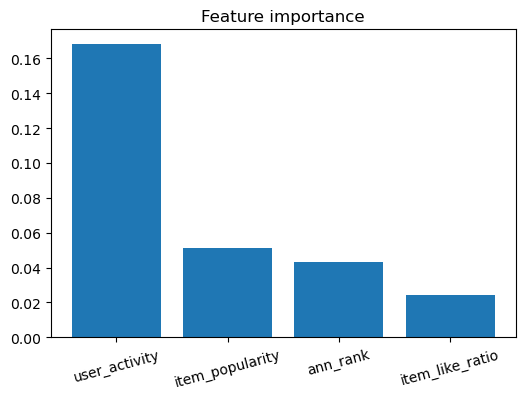

In [184]:
plt.figure(figsize=(6, 4))

plt.bar(
    imp_df["feature"],
    imp_df["importance"])

plt.title("Feature importance")
plt.xticks(rotation=15)
plt.show()

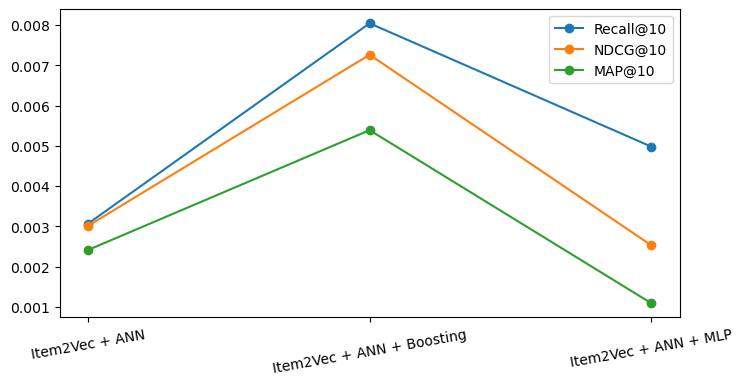

In [186]:
plt.figure(figsize=(8, 4))

x = final_df["model"]

plt.plot(x, final_df["Recall@10"], marker="o", label="Recall@10")
plt.plot(x, final_df["NDCG@10"], marker="o", label="NDCG@10")
plt.plot(x, final_df["MAP@10"], marker="o", label="MAP@10")
plt.legend()
plt.xticks(rotation=10)
plt.show()